In [2]:
import anndata
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
sc.settings.verbosity=2
sc.settings.seed=1234
np.random.seed(1234)
outdir="./ground_truth/mouse"

In [7]:
scpoli_h5ad="../../../../7_mapping_new_data/0511_rename_noIAISR/output_mouse/level1_mouse_atlas_nogene.h5ad"### all human scpoli data without gene names, but with annotation
adata_scpoli=sc.read_h5ad(scpoli_h5ad)
adata_scpoli

AnnData object with n_obs × n_vars = 566264 × 10
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'leiden', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'location', 'species', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human(measure)&mouse'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [8]:
adata_scpoli.obs

,sample,dataset,symptoms,scDblFinder.class,scDblFinder.score,scDblFinder.weighted,scDblFinder.cxds_score,decontX_contamination,decontX_clusters,n_genes_by_counts,...,intervention,tissue,atlas_key,location,species,cell_type_pred,cell_type_uncert,query,cell_type_pred_ref,cell_type_level1_human(measure)&mouse
AAACCCAAGAATCGCG-1-1,GSE239591_1,GSE239591,Atherosclerosis,singlet,0.030562,0.315915,0.033228,0.019320,GSE239591_1-1,1388,...,dietary(HFD 16wks)+medicine(ABT),Aorta,NaN,Aorta,Mouse,Macrophage,0.206430,1,Macrophage,Macrophage
AAACCCAAGACCTCCG-1-1,GSE239591_1,GSE239591,Atherosclerosis,singlet,0.000793,0.060693,0.061865,0.008698,GSE239591_1-2,1995,...,dietary(HFD 16wks)+medicine(ABT),Aorta,NaN,Aorta,Mouse,Neutrophil,0.097454,1,Neutrophil,Neutrophil
AAACCCAAGAGATCGC-1-1,GSE239591_1,GSE239591,Atherosclerosis,singlet,0.000789,0.078010,0.032850,0.017125,GSE239591_1-3,1506,...,dietary(HFD 16wks)+medicine(ABT),Aorta,NaN,Aorta,Mouse,B cell,0.139515,1,B cell,B cell
AAACCCAAGGTAAAGG-1-1,GSE239591_1,GSE239591,Atherosclerosis,singlet,0.002351,0.285856,0.013905,0.002436,GSE239591_1-4,4649,...,dietary(HFD 16wks)+medicine(ABT),Aorta,NaN,Aorta,Mouse,Fibroblast,0.073571,1,Fibroblast,Fibroblast
AAACCCACAGACGCTC-1-1,GSE239591_1,GSE239591,Atherosclerosis,singlet,0.002186,0.043793,0.039949,0.013481,GSE239591_1-3,2017,...,dietary(HFD 16wks)+medicine(ABT),Aorta,NaN,Aorta,Mouse,B cell,0.102414,1,B cell,B cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTCCAATGACAGACAAAGTTTACG-1,GSE264071_WT,GSE264071,AAA,singlet,0.000617,0.097724,0.009345,0.195225,GSE264071_WT-1,574,...,PPE,Abdominal Aorta,NaN,Aorta,Mouse,Erythrocyte/Erythroid,0.492281,1,Erythrocyte/Erythroid,Erythrocyte/Erythroid
TTGTTCCAATTCCATTGAAACGTGTGA-1,GSE264071_WT,GSE264071,AAA,singlet,0.383547,0.249081,0.168891,0.062926,GSE264071_WT-1,4022,...,PPE,Abdominal Aorta,NaN,Aorta,Mouse,Fibroblast,0.179932,1,Fibroblast,Fibroblast
TTGTTCCAATTCCATTGAAATGTATCG-1,GSE264071_WT,GSE264071,AAA,singlet,0.013390,0.302170,0.037089,0.021720,GSE264071_WT-2,1274,...,PPE,Abdominal Aorta,NaN,Aorta,Mouse,Macrophage,0.120764,1,Macrophage,Macrophage
TTGTTCCAATTCCATTGAAGCCTGGTT-1,GSE264071_WT,GSE264071,AAA,singlet,0.012190,0.141816,0.111481,0.044750,GSE264071_WT-1,2981,...,PPE,Abdominal Aorta,NaN,Aorta,Mouse,Fibroblast,0.129425,1,Fibroblast,Fibroblast


In [17]:
adata_scpoli.obs.index = adata_scpoli.obs.index.str[:-2]
adata_scpoli.obs

,sample,dataset,symptoms,scDblFinder.class,scDblFinder.score,scDblFinder.weighted,scDblFinder.cxds_score,decontX_contamination,decontX_clusters,n_genes_by_counts,...,tissue,atlas_key,location,species,cell_type_pred,cell_type_uncert,query,cell_type_pred_ref,cell_type_level1_human(measure)&mouse,ground_truth
AAACCCAAGAATCGCG-1,GSE239591_1,GSE239591,Atherosclerosis,singlet,0.030562,0.315915,0.033228,0.019320,GSE239591_1-1,1388,...,Aorta,NaN,Aorta,Mouse,Macrophage,0.206430,1,Macrophage,Macrophage,NaN
AAACCCAAGACCTCCG-1,GSE239591_1,GSE239591,Atherosclerosis,singlet,0.000793,0.060693,0.061865,0.008698,GSE239591_1-2,1995,...,Aorta,NaN,Aorta,Mouse,Neutrophil,0.097454,1,Neutrophil,Neutrophil,NaN
AAACCCAAGAGATCGC-1,GSE239591_1,GSE239591,Atherosclerosis,singlet,0.000789,0.078010,0.032850,0.017125,GSE239591_1-3,1506,...,Aorta,NaN,Aorta,Mouse,B cell,0.139515,1,B cell,B cell,NaN
AAACCCAAGGTAAAGG-1,GSE239591_1,GSE239591,Atherosclerosis,singlet,0.002351,0.285856,0.013905,0.002436,GSE239591_1-4,4649,...,Aorta,NaN,Aorta,Mouse,Fibroblast,0.073571,1,Fibroblast,Fibroblast,NaN
AAACCCACAGACGCTC-1,GSE239591_1,GSE239591,Atherosclerosis,singlet,0.002186,0.043793,0.039949,0.013481,GSE239591_1-3,2017,...,Aorta,NaN,Aorta,Mouse,B cell,0.102414,1,B cell,B cell,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTCCAATGACAGACAAAGTTTACG,GSE264071_WT,GSE264071,AAA,singlet,0.000617,0.097724,0.009345,0.195225,GSE264071_WT-1,574,...,Abdominal Aorta,NaN,Aorta,Mouse,Erythrocyte/Erythroid,0.492281,1,Erythrocyte/Erythroid,Erythrocyte/Erythroid,NaN
TTGTTCCAATTCCATTGAAACGTGTGA,GSE264071_WT,GSE264071,AAA,singlet,0.383547,0.249081,0.168891,0.062926,GSE264071_WT-1,4022,...,Abdominal Aorta,NaN,Aorta,Mouse,Fibroblast,0.179932,1,Fibroblast,Fibroblast,NaN
TTGTTCCAATTCCATTGAAATGTATCG,GSE264071_WT,GSE264071,AAA,singlet,0.013390,0.302170,0.037089,0.021720,GSE264071_WT-2,1274,...,Abdominal Aorta,NaN,Aorta,Mouse,Macrophage,0.120764,1,Macrophage,Macrophage,NaN
TTGTTCCAATTCCATTGAAGCCTGGTT,GSE264071_WT,GSE264071,AAA,singlet,0.012190,0.141816,0.111481,0.044750,GSE264071_WT-1,2981,...,Abdominal Aorta,NaN,Aorta,Mouse,Fibroblast,0.129425,1,Fibroblast,Fibroblast,NaN


In [18]:
gt = pd.read_csv("./GSM6456204_Control_Cell_Barcode_Anno.csv",sep="\t")
print(gt.columns)

Index(['Cell name', 'Sample name', 'Classification'], dtype='object')


In [19]:
gt

,Cell name,Sample name,Classification
0,AAACCTGAGAGACTTA-1,Control,ECs
1,AAACCTGAGAGTGAGA-1,Control,Mac
2,AAACCTGAGATCCGAG-1,Control,ECs
3,AAACCTGAGCTTATCG-1,Control,VSMCs-2
4,AAACCTGAGTCACGCC-1,Control,Fib-1
...,...,...,...
3055,TTTGGTTGTCCAGTGC-1,Control,Mac
3056,TTTGGTTTCATATCGG-1,Control,Fib-3
3057,TTTGTCAAGAGTCTGG-1,Control,VSMCs-1
3058,TTTGTCACATCTGGTA-1,Control,Mac


In [20]:
# 建立 cell name -> Classification 的映射
gt_map = gt.set_index("Cell name")["Classification"]

# 按 adata_scpoli.obs_names 匹配加入 obs
adata_scpoli.obs["ground_truth"] = adata_scpoli.obs_names.map(gt_map)

# 检查匹配情况
print(adata_scpoli.obs["ground_truth"].isna().sum())
print(adata_scpoli.obs["ground_truth"].value_counts(dropna=False))

563356
ground_truth
NaN           563356
Fib-2            907
Mac              498
VSMCs-2          496
ECs              347
Fib-1            290
Fib-3            117
VSMCs-1          112
Foam cells        35
NKT Cells         32
MoDC              27
B Cells           26
T cells           12
Mono               9
Name: count, dtype: int64


In [21]:
adata_scpoli = adata_scpoli[~adata_scpoli.obs["ground_truth"].isna()].copy()
adata_scpoli.write("./mouse_ground_truth.h5ad")

In [25]:
adata_scpoli

AnnData object with n_obs × n_vars = 2908 × 10
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'leiden', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'location', 'species', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human(measure)&mouse', 'ground_truth'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

去除指定细胞类型后共有 2908 个细胞
共同匹配到 2908 个细胞

Ground truth cell types from Atlas_AS_NC.h5ad:
['B Cells', 'ECs', 'Fib-1', 'Fib-2', 'Fib-3', 'Foam cells', 'Mac', 'MoDC', 'Mono', 'NKT Cells', 'T cells', 'VSMCs-1', 'VSMCs-2']

Predicted cell types from current adata:
['B cell', 'Basophil', 'Dendritic cell', 'Endothelial cell', 'Erythrocyte/Erythroid', 'Fibroblast', 'Macrophage', 'Monocyte', 'Natural killer cell', 'Neutrophil', 'Pericyte', 'Smooth muscle cell', 'T cell']

Accuracy: 0.0000
Weighted precision: 0.0000
Weighted recall: 0.0000

每列百分比加和:
[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]


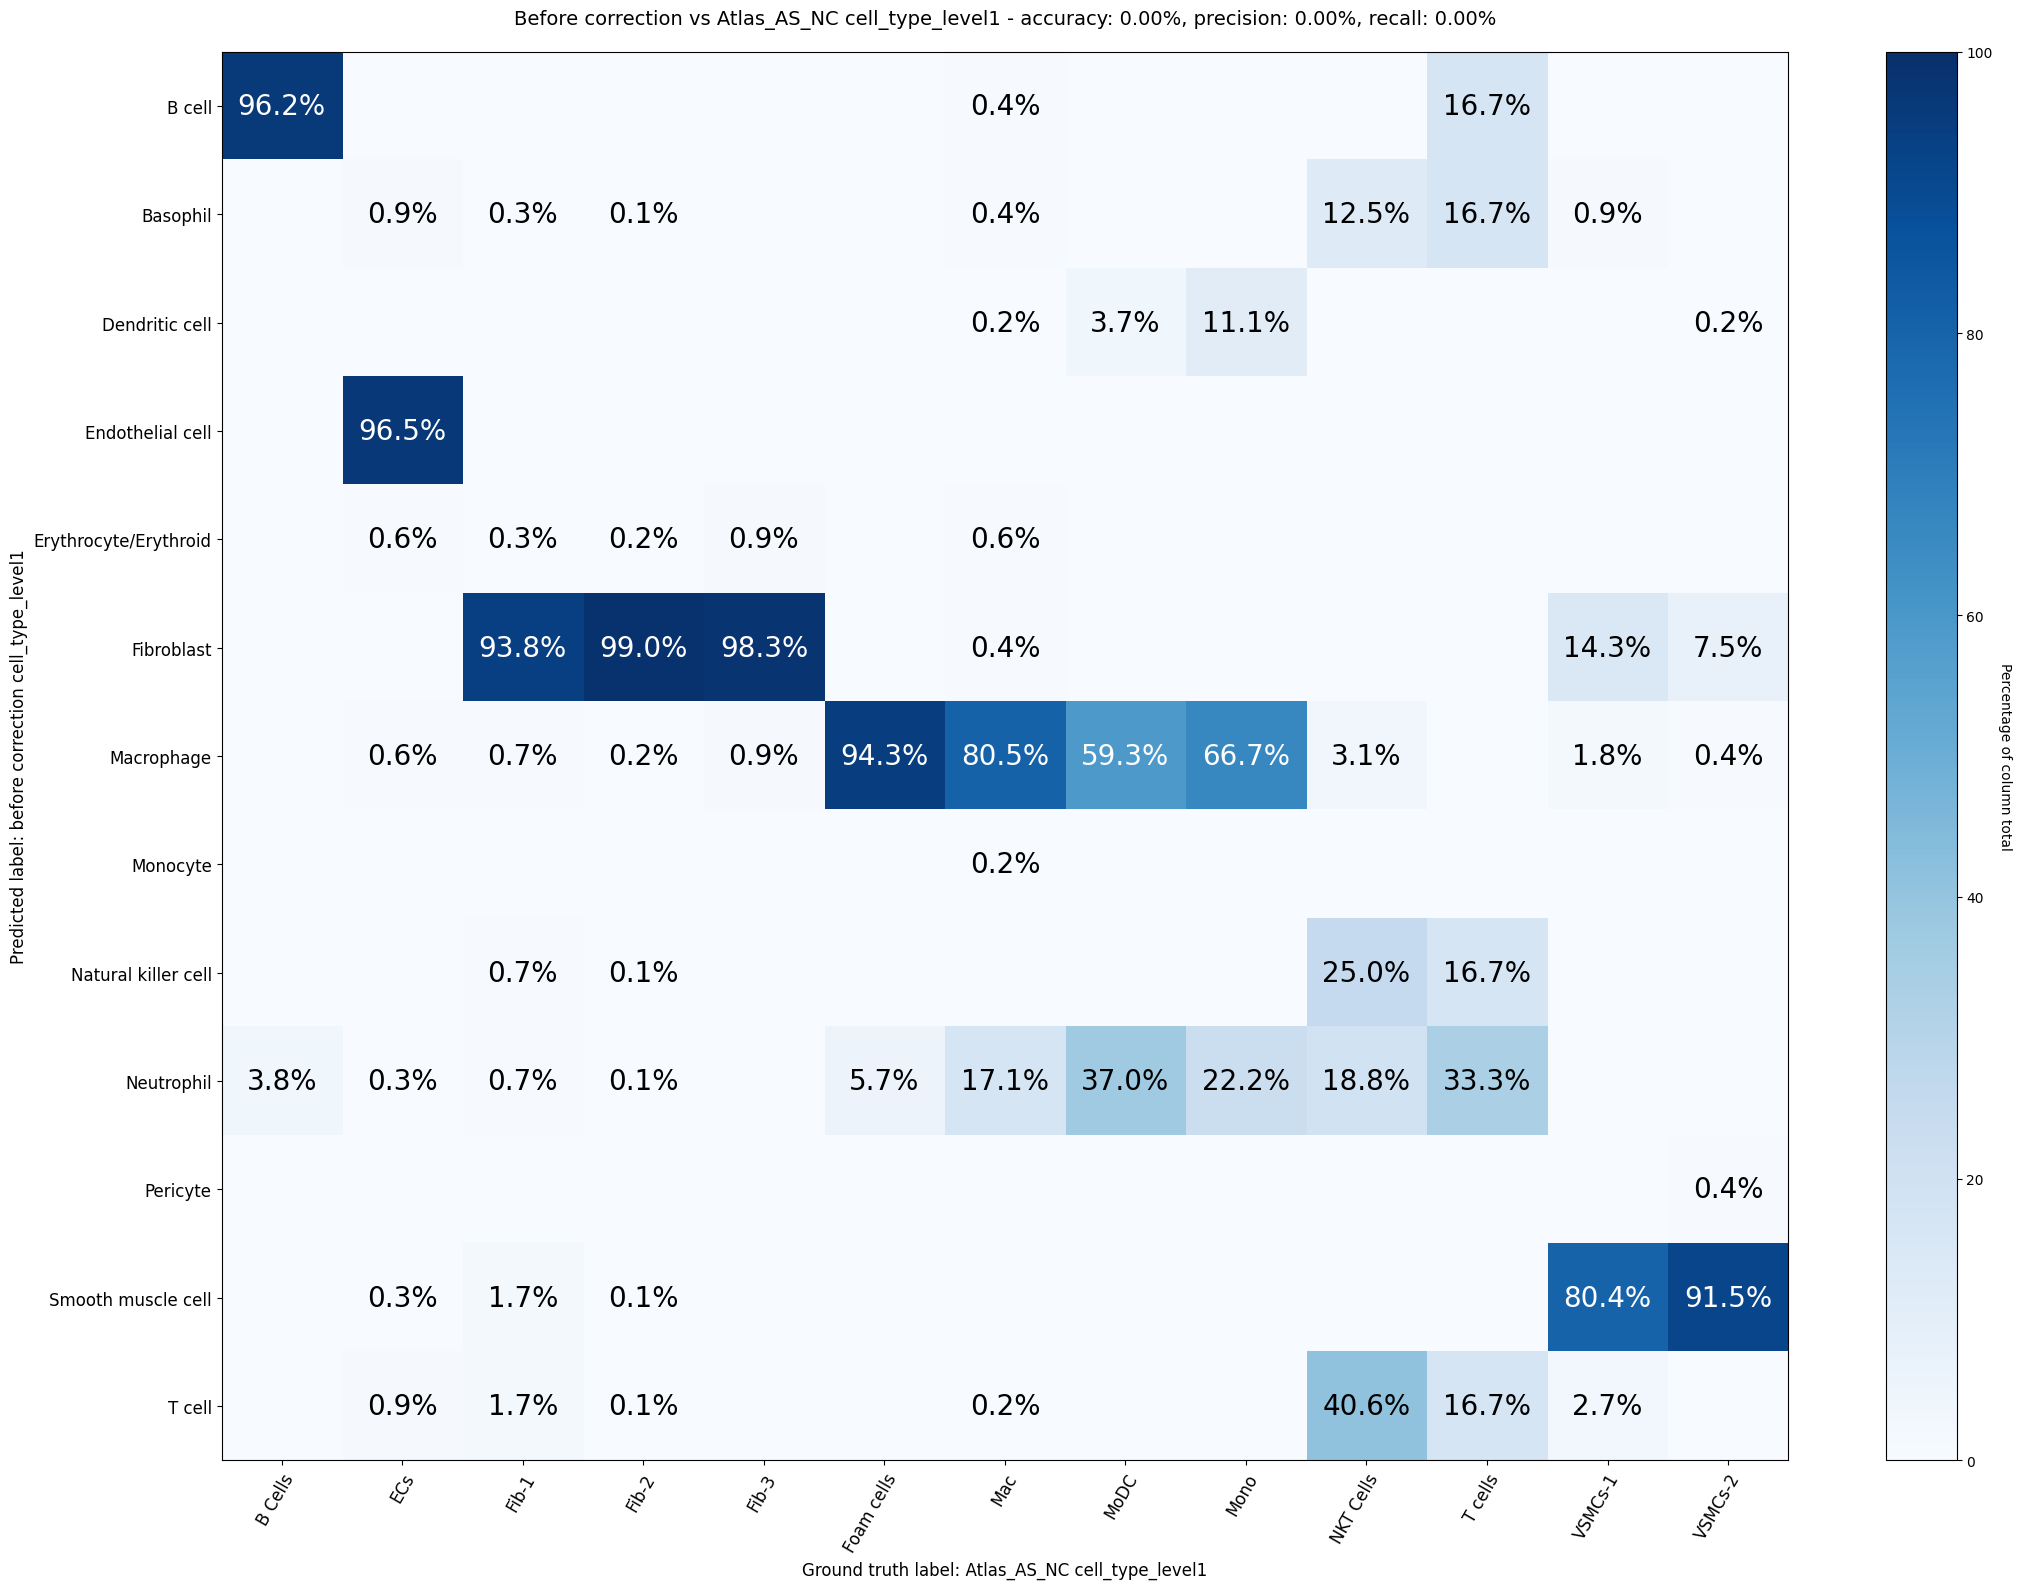


Per-predicted-cell-type precision:
                cell_type  precision
0                  B cell        0.0
1                Basophil        0.0
2          Dendritic cell        0.0
3        Endothelial cell        0.0
4   Erythrocyte/Erythroid        0.0
5              Fibroblast        0.0
6              Macrophage        0.0
7                Monocyte        0.0
8     Natural killer cell        0.0
9              Neutrophil        0.0
10               Pericyte        0.0
11     Smooth muscle cell        0.0
12                 T cell        0.0

Per-ground-truth-cell-type recall:
     cell_type  recall
0      B Cells     0.0
1          ECs     0.0
2        Fib-1     0.0
3        Fib-2     0.0
4        Fib-3     0.0
5   Foam cells     0.0
6          Mac     0.0
7         MoDC     0.0
8         Mono     0.0
9    NKT Cells     0.0
10     T cells     0.0
11     VSMCs-1     0.0
12     VSMCs-2     0.0


In [ ]:
###校正前
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
from matplotlib import colors


obs_before=adata_scpoli.obs[["cell_type_level1_human(measure)&mouse"]].copy()
obs_before.index=adata_scpoli.obs_names.copy()
obs_ref=adata_scpoli.obs[["ground_truth"]].copy()
obs_ref.index=adata_scpoli.obs_names.copy()

adata_scpoli.file.close()

# obs_before=obs_before[~obs_before["cell_type_level1"].isin(remove_cell_types)]
common_indices=obs_before.index.intersection(obs_ref.index)

# print(f"当前 AnnData 中共有 {n_obs_before} 个细胞")
print(f"去除指定细胞类型后共有 {obs_before.shape[0]} 个细胞")
# print(f"参考 AnnData 中共有 {n_obs_ref} 个细胞")
print(f"共同匹配到 {len(common_indices)} 个细胞")

compare_df=pd.DataFrame({
    "pred":obs_before.loc[common_indices,"cell_type_level1_human(measure)&mouse"].astype(str),
    "gt":obs_ref.loc[common_indices,"ground_truth"].astype(str)
})

mapped_cell_types=compare_df["gt"].values
cell_types_pred=compare_df["pred"].values

gt_cell_types=sorted(compare_df["gt"].unique())
pred_cell_types=sorted(compare_df["pred"].unique())

print("\nGround truth cell types from Atlas_AS_NC.h5ad:")
print(gt_cell_types)
print("\nPredicted cell types from current adata:")
print(pred_cell_types)

conf_df=pd.crosstab(
    pd.Categorical(compare_df["pred"],categories=pred_cell_types),
    pd.Categorical(compare_df["gt"],categories=gt_cell_types),
    rownames=["Predicted label"],
    colnames=["Ground truth label"],
    dropna=False
)

conf_matrix=conf_df.to_numpy()
accuracy=accuracy_score(mapped_cell_types,cell_types_pred)

precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    labels=pred_cell_types,
    average=None,
    zero_division=0
)

recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    labels=gt_cell_types,
    average=None,
    zero_division=0
)

overall_precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

overall_recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted precision: {overall_precision:.4f}")
print(f"Weighted recall: {overall_recall:.4f}")

col_sums=conf_matrix.sum(axis=0,keepdims=True)
conf_matrix_percentages=np.divide(
    conf_matrix,
    col_sums,
    out=np.zeros_like(conf_matrix,dtype=float),
    where=col_sums!=0
)*100

print("\n每列百分比加和:")
print(conf_matrix_percentages.sum(axis=0))

fig,ax=plt.subplots(figsize=(22,16))
norm=colors.Normalize(vmin=0,vmax=100)

im=ax.imshow(
    conf_matrix_percentages,
    interpolation="nearest",
    cmap=plt.cm.Blues,
    norm=norm,
    aspect="auto"
)

cbar=ax.figure.colorbar(im,ax=ax)
cbar.ax.set_ylabel("Percentage of column total",rotation=-90,va="bottom")

ax.set(
    xticks=np.arange(len(gt_cell_types)),
    yticks=np.arange(len(pred_cell_types)),
    xticklabels=gt_cell_types,
    yticklabels=pred_cell_types,
    title=(
        f"Before correction vs Atlas_AS_NC cell_type_level1 - "
        f"accuracy: {accuracy:.2%}, "
        f"precision: {overall_precision:.2%}, "
        f"recall: {overall_recall:.2%}"
    ),
    ylabel="Predicted label: before correction cell_type_level1",
    xlabel="Ground truth label: Atlas_AS_NC cell_type_level1"
)

plt.setp(ax.get_xticklabels(),rotation=60,ha="right",rotation_mode="anchor",fontsize=12)
plt.setp(ax.get_yticklabels(),fontsize=12)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        if conf_matrix[i,j]>0:
            ax.text(
                j,
                i,
                # str(conf_matrix[i,j]),
                f"{conf_matrix_percentages[i,j]:.1f}%",
                ha="center",
                va="center",
                fontsize=20,
                color="white" if conf_matrix_percentages[i,j]>50 else "black"
            )

ax.set_title(ax.get_title(),fontsize=14,pad=20)
ax.set_xlabel("Ground truth label: Atlas_AS_NC cell_type_level1",fontsize=12)
ax.set_ylabel("Predicted label: before correction cell_type_level1",fontsize=12)

fig.tight_layout()

# plt.savefig(os.path.join(outdir, "verify_before_correction.png"),dpi=200)
plt.show()

precision_df=pd.DataFrame({"cell_type":pred_cell_types,"precision":precision})
recall_df=pd.DataFrame({"cell_type":gt_cell_types,"recall":recall})

print("\nPer-predicted-cell-type precision:")
print(precision_df)

print("\nPer-ground-truth-cell-type recall:")
print(recall_df)